In [ ]:
print('Hello')

Hello


> **Linear regression is used to predict the numerical value**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

data = pd.DataFrame({
    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
                        3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
                        6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],

    'Branch': np.random.choice(['IT', 'ENTC', 'Mechanical'], 30),

    'Age': np.random.randint(21, 35, 30),

    'Education': np.random.choice(
        ['B.Tech', 'M.Tech', 'MBA'], 30
    ),

    'City': np.random.choice(
        ['Pune', 'Mumbai', 'Bangalore', 'Hyderabad'], 30
    ),

    'Projects': np.random.randint(1, 11, 30),

    'Certifications': np.random.randint(0, 6, 30),

    'PerformanceScore': np.random.randint(60, 101, 30),

    'OvertimeHours': np.random.randint(0, 31, 30),

    'Salary': [
        39343, 46205, 37731, 43525, 39891, 56642,
        60150, 54445, 64445, 57189, 63218, 55794,
        56957, 57081, 61111, 67938, 66029, 83088,
        81363, 93940, 91738, 98273, 101302, 113812,
        109431, 105582, 116969, 112635, 122391, 121872
    ]
})

df=data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YearsExperience   30 non-null     float64
 1   Branch            30 non-null     object 
 2   Age               30 non-null     int64  
 3   Education         30 non-null     object 
 4   City              30 non-null     object 
 5   Projects          30 non-null     int64  
 6   Certifications    30 non-null     int64  
 7   PerformanceScore  30 non-null     int64  
 8   OvertimeHours     30 non-null     int64  
 9   Salary            30 non-null     int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 2.5+ KB


In [ ]:
df = pd.get_dummies(
    data,
    columns=['Branch', 'Education', 'City'],
    drop_first=True
)

X = df.drop('Salary', axis=1)
y = df['Salary']

In [ ]:
df.head()

,YearsExperience,Age,Projects,Certifications,PerformanceScore,OvertimeHours,Salary,Branch_IT,Branch_Mechanical,Education_M.Tech,Education_MBA,City_Hyderabad,City_Mumbai,City_Pune
0,1.1,30,1,1,79,16,39343,False,True,False,True,False,True,False
1,1.3,32,5,3,89,23,46205,True,False,False,True,False,False,False
2,1.5,32,10,4,70,16,37731,False,True,False,False,False,False,True
3,2.0,34,7,2,87,26,43525,False,True,False,True,True,False,False
4,2.2,34,10,0,84,16,39891,True,False,False,True,False,True,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   YearsExperience    30 non-null     float64
 1   Age                30 non-null     int64  
 2   Projects           30 non-null     int64  
 3   Certifications     30 non-null     int64  
 4   PerformanceScore   30 non-null     int64  
 5   OvertimeHours      30 non-null     int64  
 6   Salary             30 non-null     int64  
 7   Branch_IT          30 non-null     bool   
 8   Branch_Mechanical  30 non-null     bool   
 9   Education_M.Tech   30 non-null     bool   
 10  Education_MBA      30 non-null     bool   
 11  City_Hyderabad     30 non-null     bool   
 12  City_Mumbai        30 non-null     bool   
 13  City_Pune          30 non-null     bool   
dtypes: bool(7), float64(1), int64(6)
memory usage: 2.0 KB


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
x_train , x_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
x= df.drop('Salary', axis=1)
y= df['Salary']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test_scaled)
y_pred

array([108608.56193432,  79401.27576051, 112829.03718317,  70846.78993635,
        48798.03011054,  56510.43134874])

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 74207.625
Coefficients: [26916.02878361  1232.31043288 -3142.8312522  -1716.71440502
   770.44994404 -1873.20101195   598.20093388  -309.06286899
 -2635.44075418  -950.73495037   466.62817758 -2378.87890403
  -844.49877711]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("R2 Score in percentage:", int((r2)*100))

MAE : 7506.5708745653765
MSE : 90620076.08601241
RMSE: 9519.457762184378
R2 Score: 0.8225904547121208
R2 Score in percentage: 82


In [ ]:
result = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})


In [ ]:
result

,Actual Salary,Predicted Salary
0,112635,108608.561934
1,67938,79401.275761
2,113812,112829.037183
3,83088,70846.789936
4,64445,48798.030111
5,57189,56510.431349


#**PREDICTION OF NEW DATA**

In [ ]:
new_employee_data = pd.DataFrame({
    'YearsExperience': [7.5],  # Example: 7.5 years experience
    'Branch': ['IT'],          # Example: IT branch
    'Age': [28],               # Example: 28 years old
    'Education': ['M.Tech'],   # Example: M.Tech education
    'City': ['Mumbai'],        # Example: Mumbai city
    'Projects': [6],           # Example: 6 projects
    'Certifications': [3],     # Example: 3 certifications
    'PerformanceScore': [92],  # Example: Performance score of 92
    'OvertimeHours': [15]      # Example: 15 overtime hours
})

# Apply dummy encoding to the new data, consistent with training data
new_employee_processed = pd.get_dummies(
    new_employee_data,
    columns=['Branch', 'Education', 'City'],
    drop_first=True
)

# Ensure all columns from the original X are present in new_employee_processed
# and in the same order. Fill missing columns with False (for one-hot encoded categories not present)
# and handle extra columns if any.
# Get the columns from the original X that were used for training
training_columns = X.columns

# Add missing columns to new_employee_processed with False
missing_cols = set(training_columns) - set(new_employee_processed.columns)
for c in missing_cols:
    new_employee_processed[c] = False

# Drop any extra columns that might be in new_employee_processed but not in training_columns
extra_cols = set(new_employee_processed.columns) - set(training_columns)
new_employee_processed = new_employee_processed.drop(columns=list(extra_cols))

# Reorder columns to match the training data
new_employee_processed = new_employee_processed[training_columns]

# Scale the new data using the *fitted* scaler
new_employee_scaled = scaler.transform(new_employee_processed)

# Predict the salary for the new employee
predicted_salary = model.predict(new_employee_scaled)

print(f"Predicted Salary for new employee: ${predicted_salary[0]:,.2f}")

Predicted Salary for new employee: $100,464.42


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


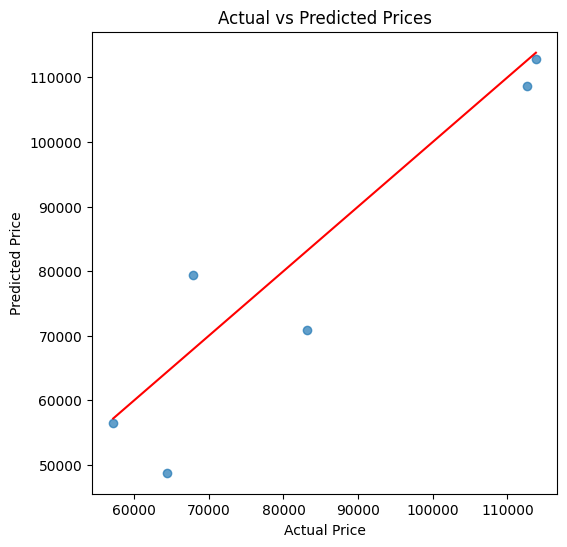

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

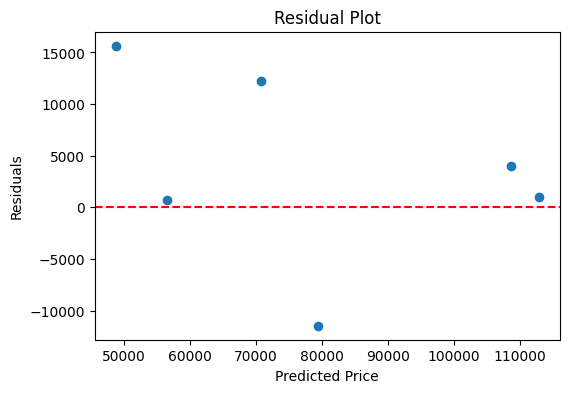

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

/tmp/ipykernel_1760/1338754823.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=y_pred , y=y_test , palette='rainbow')


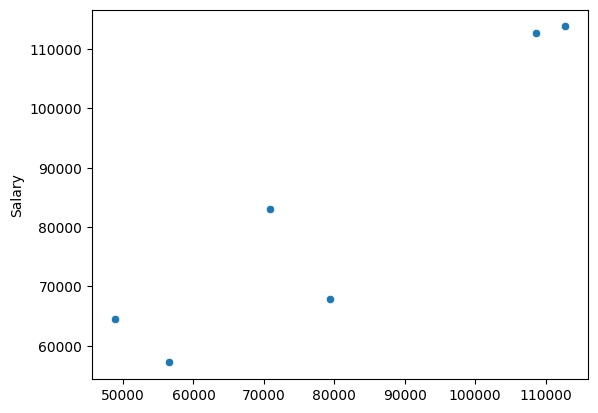

In [ ]:
sns.scatterplot(x=y_pred , y=y_test , palette='rainbow')
plt.show()

in beak take input from user and predict the values on it